### Domain  : Power
### Dataset : Solar Power Generation Data

#### About Dataset
This data has been gathered at one solar power plant in India over a 34‑day period. It consists of a pair of files:

One file contains power generation data collected at the inverter level. Each inverter has multiple lines of solar panels attached to it, so the dataset captures detailed generation performance across the plant’s inverters.

The other file contains sensor readings collected at the plant level. These readings come from a single array of sensors optimally placed within the plant to monitor environmental and operational conditions.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Datasets

In [2]:
# Load generation data
gen1 = pd.read_csv("Plant_1_Generation_Data.csv")

# Load weather sensor data
weather1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

### View Basic Information

In [3]:
print(gen1.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  


Description of the variables

DATE_TIME - Date and time for each observation. Observations recorded at 15 minute intervals.

PLANT_ID -  this will be common for the entire file.

SOURCE_KEY - Source key in this file stands for the inverter id.

DC_POWER - Amount of DC power generated by the inverter (source_key) in this 15 minute interval. Units - kW.

AC_POWER - Amount of AC power generated by the inverter (source_key) in this 15 minute interval. Units - kW.

DAILY_YIELD - Daily yield is a cumulative sum of power generated on that day, till that point in time.

TOTAL_YIELD - This is the total yield for the inverter till that point in time.

In [4]:
print(weather1.head())

             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135001  HmiyD2TTLFNqkNe            24.621525   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.761668          0.0  
2           22.592306          0.0  
3           22.360852          0.0  
4           22.165423          0.0  


Description of the variable

DATE_TIME - Date and time for each observation. Observations recorded at 15 minute intervals.

PLANT_ID - Plant ID - this will be common for the entire file.

SOURCE_KEY - Stands for the sensor panel id. This will be common for the entire file because there's only one sensor panel 

AMBIENT_TEMPERATURE - This is the ambient temperature at the plant.

MODULE_TEMPERATURE - There's a module (solar panel) attached to the sensor panel. This is the temperature reading for that module.

IRRADIATION - Amount of irradiation for the 15 minute interval.

### Shape of Dataset

In [5]:
print("Generation_dataset:",gen1.shape)

print("Weather_dataset:",weather1.shape)

Generation_dataset: (68778, 7)
Weather_dataset: (3182, 6)


The Generation dataset contains 68,778 records with 11 features, while the Weather dataset contains 3,182 records with 6 features, indicating a large amount of operational and environmental data available for solar power analysis.

### Column Names

In [6]:
print("Generation_dataset:",gen1.columns)

Generation_dataset: Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='str')


In [7]:
print("Weather_dataset:",weather1.columns)

Weather_dataset: Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='str')


### Dataset Information

In [8]:
print("Generation_dataset:",gen1.info())

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 5.7 MB
Generation_dataset: None


The generation dataset contains 68,778 records and 7 columns with no missing values, indicating a complete and well-structured dataset containing solar power generation details such as DC power, AC power, daily yield, and total yield, suitable for further preprocessing and analysis.

In [9]:
print("Weather_dataset:",weather1.info())

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 254.9 KB
Weather_dataset: None


The weather dataset contains 3,182 records and 6 columns with no missing values, providing complete environmental information such as ambient temperature, module temperature, and irradiation, which are important factors influencing solar power generation and plant efficiency.

### Check Missing Values

In [10]:
print(gen1.isnull().sum())

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


In [11]:
print(weather1.isnull().sum())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


### Check Duplicate Rows

In [12]:
print(gen1.duplicated().sum())

0


In [13]:
print(weather1.duplicated().sum())

0


### Convert Date-Time Column

In [14]:
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13132\1041210191.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])


In [15]:
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])

The DATE_TIME column in both generation and weather datasets was converted from string format to datetime format, enabling efficient time-based analysis such as hourly, daily, and monthly solar power trend evaluation.

### Check Data Types

In [16]:
print(gen1.dtypes)

DATE_TIME      datetime64[us]
PLANT_ID                int64
SOURCE_KEY                str
DC_POWER              float64
AC_POWER              float64
DAILY_YIELD           float64
TOTAL_YIELD           float64
dtype: object


In [17]:
print(weather1.dtypes)

DATE_TIME              datetime64[us]
PLANT_ID                        int64
SOURCE_KEY                        str
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
dtype: object


### Extract Time Features (Feature Engineering)

#### Hour

In [18]:
gen1['HOUR'] = gen1['DATE_TIME'].dt.hour

#### Day

In [19]:
gen1['DAY'] = gen1['DATE_TIME'].dt.day

#### Month

In [20]:
gen1['MONTH'] = gen1['DATE_TIME'].dt.month

#### Weekday

In [21]:
gen1['WEEKDAY'] = gen1['DATE_TIME'].dt.day_name()

The extraction of HOUR, DAY, MONTH, and WEEKDAY features from the DATE_TIME column enables detailed time-based analysis of solar power generation patterns, helping identify hourly trends, daily variations, monthly seasonal behavior, and weekday-wise performance.

### Merge Generation and Weather Data

In [22]:
merged_data = pd.merge(
    gen1,
    weather1,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner')

The generation and weather datasets were merged using DATE_TIME and PLANT_ID, creating a unified dataset that combines solar power generation data with environmental conditions for more comprehensive analysis.

### View Merged Dataset

In [23]:
print(merged_data.head())

   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  HOUR  DAY  MONTH WEEKDAY     SOURCE_KEY_y  \
0    6259559.0     0   15      5  Friday  HmiyD2TTLFNqkNe   
1    6183645.0     0   15      5  Friday  HmiyD2TTLFNqkNe   
2    6987759.0     0   15      5  Friday  HmiyD2TTLFNqkNe   
3    7602960.0     0   15      5  Friday  HmiyD2TTLFNqkNe   
4    7158964.0     0   15      5  Friday  HmiyD2TTLFNqkNe   

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
0            25.184316           22.857507          0.0  
1            25.184316           22.857507          0.0  
2 

In [24]:
print(merged_data.shape)

(68774, 15)


After merging, the combined dataset contains 68,774 rows and 15 columns, indicating that most generation records successfully matched with corresponding weather data, resulting in a comprehensive dataset for solar power and environmental analysis.

### Create New Features

#### i) Power Efficiency

In [25]:
merged_data['EFFICIENCY'] = np.where(
    merged_data['DC_POWER'] != 0,
    merged_data['AC_POWER'] / merged_data['DC_POWER'],
    0)

##### Efficiency formula:

Efficiency=
AC_POWER/
DC_POWER

The efficiency feature is created to measure how effectively the solar plant converts generated DC power into usable AC power.

DC_POWER is the raw power produced by solar panels.

AC_POWER is the usable power after conversion through the inverter.

##### Importance of efficiency:

Higher efficiency indicates better plant and inverter performance.

Lower efficiency may indicate:
energy losses,
overheating,
inverter issues,
shading or weather effects.

It helps compare performance under different environmental conditions.

The efficiency feature measures the effectiveness of converting DC power into usable AC power, helping evaluate solar plant performance and energy conversion quality.

#### ii)Temperature Difference

In [26]:
merged_data['TEMP_DIFF'] = (
    merged_data['MODULE_TEMPERATURE'] -
    merged_data['AMBIENT_TEMPERATURE'])

Temperature Difference=MODULE_TEMPERATURE−

AMBIENT_TEMPERATURE represents the surrounding air temperature.

MODULE_TEMPERATURE represents the actual temperature of the solar panel.

The difference shows the amount of heat absorbed by the panel during operation.

##### Importance of Temperature Difference

High panel temperatures can reduce solar panel efficiency.

Large temperature differences may indicate:
excessive heating,
strong sunlight exposure,
reduced cooling efficiency.

It helps analyze the thermal behavior of the solar plant and its impact on power generation.

The TEMP_DIFF feature measures the temperature rise of solar panels above ambient conditions, helping analyze thermal effects on solar plant performance and efficiency.

### Detect Outliers Using Boxplot

In [27]:
columns = [
    'AC_POWER',
    'DC_POWER',
    'DAILY_YIELD',
    'TOTAL_YIELD',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION'
]

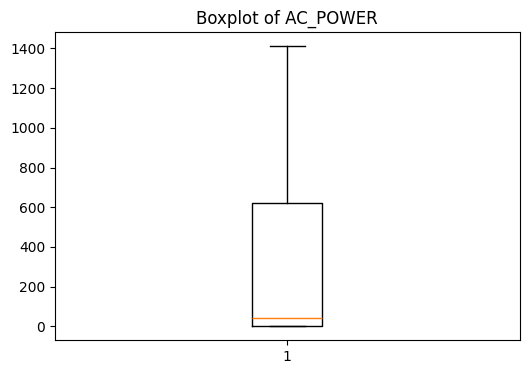

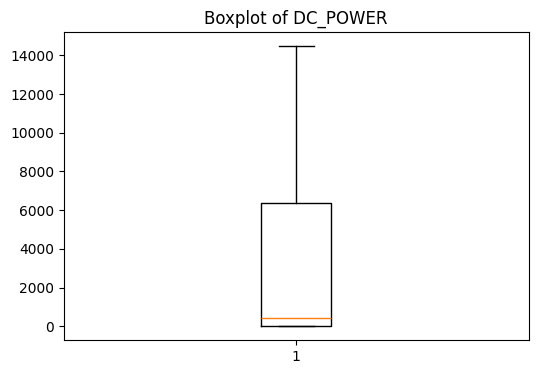

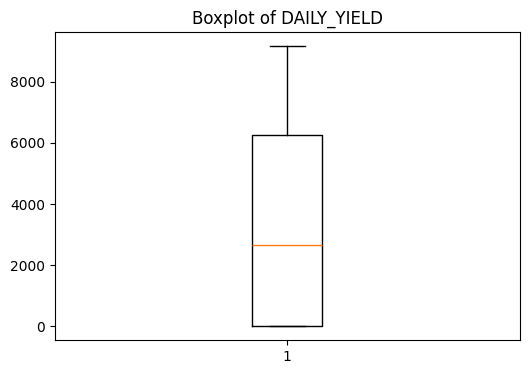

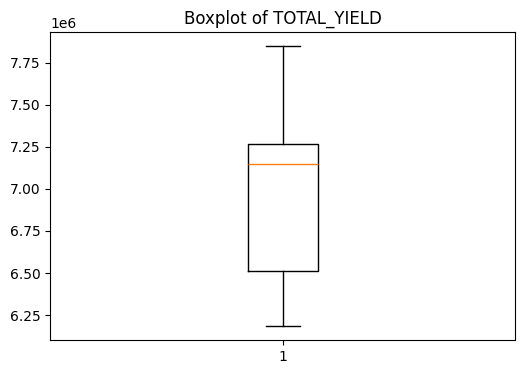

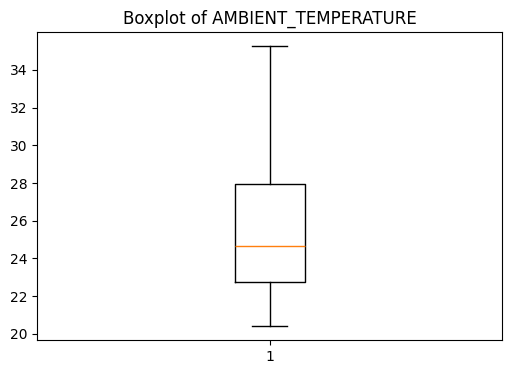

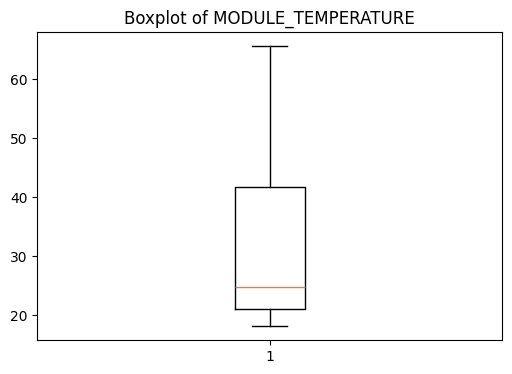

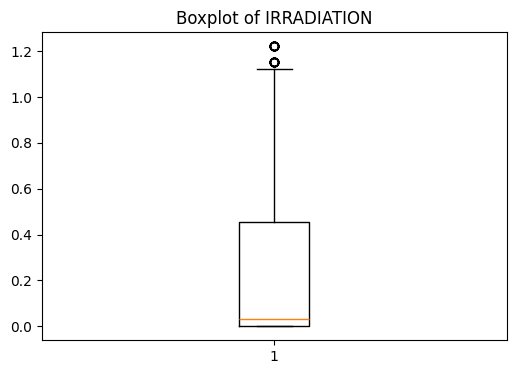

In [28]:
for col in columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(merged_data[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

### Detect Outliers Using IQR Method

In [29]:
for col in columns:
    Q1 = merged_data[col].quantile(0.25)
    Q3 = merged_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = merged_data[
        (merged_data[col] < lower) |
        (merged_data[col] > upper)]
    print(f"{col} Outliers:", outliers.shape[0])

AC_POWER Outliers: 0
DC_POWER Outliers: 0
DAILY_YIELD Outliers: 0
TOTAL_YIELD Outliers: 0
AMBIENT_TEMPERATURE Outliers: 0
MODULE_TEMPERATURE Outliers: 0
IRRADIATION Outliers: 44


### Handle Outliers

In [30]:
cleaned_data = merged_data.copy()
for col in columns:
    Q1 = cleaned_data[col].quantile(0.25)
    Q3 = cleaned_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cleaned_data = cleaned_data[
        (cleaned_data[col] >= lower) &
        (cleaned_data[col] <= upper) ]
print("Outliers removed successfully")

Outliers removed successfully


In [31]:
cleaned_data

,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,HOUR,DAY,MONTH,WEEKDAY,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,EFFICIENCY,TEMP_DIFF
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0,0,15,5,Friday,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0.0,-2.326809
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0,0,15,5,Friday,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0.0,-2.326809
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0,0,15,5,Friday,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0.0,-2.326809
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0,0,15,5,Friday,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0.0,-2.326809
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0,0,15,5,Friday,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,0.0,-2.326809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68769,2020-06-17 23:45:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0,23,17,6,Wednesday,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,0.0,-1.481315
68770,2020-06-17 23:45:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0,23,17,6,Wednesday,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,0.0,-1.481315
68771,2020-06-17 23:45:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0,23,17,6,Wednesday,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,0.0,-1.481315
68772,2020-06-17 23:45:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0,23,17,6,Wednesday,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,0.0,-1.481315


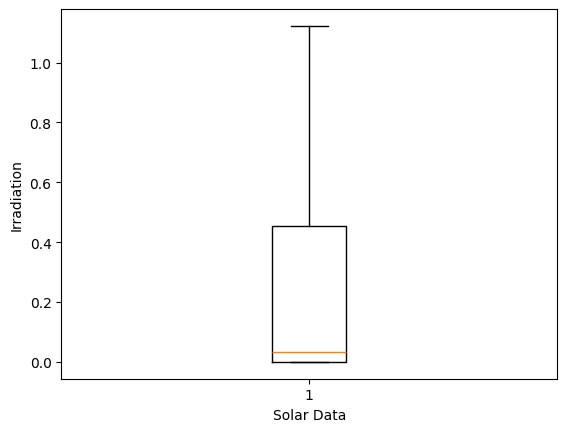

In [32]:
plt.boxplot(cleaned_data['IRRADIATION'])
plt.ylabel("Irradiation")
plt.xlabel("Solar Data")
plt.show()

We can see that the outliers are removed successfully from the feature "IRRADIATION"

Outliers were removed cautiously to avoid losing genuine operational variations.

### Check Statistical Summary

In [33]:
print(merged_data.describe())

                        DATE_TIME   PLANT_ID      DC_POWER      AC_POWER  \
count                       68774    68774.0  68774.000000  68774.000000   
mean   2020-06-01 08:02:38.161514  4135001.0   3147.177450    307.778375   
min           2020-05-15 00:00:00  4135001.0      0.000000      0.000000   
25%           2020-05-24 00:33:45  4135001.0      0.000000      0.000000   
50%           2020-06-01 14:15:00  4135001.0    428.571429     41.450000   
75%           2020-06-09 20:00:00  4135001.0   6365.468750    623.561161   
max           2020-06-17 23:45:00  4135001.0  14471.125000   1410.950000   
std                           NaN        0.0   4036.441826    394.394865   

        DAILY_YIELD   TOTAL_YIELD          HOUR           DAY         MONTH  \
count  68774.000000  6.877400e+04  68774.000000  68774.000000  68774.000000   
mean    3295.834644  6.978728e+06     11.567075     15.762876      5.518539   
min        0.000000  6.183645e+06      0.000000      1.000000      5.000000   

The statistical summary shows that solar power generation and irradiation vary significantly across different time periods, with peak AC/DC power generation occurring during high sunlight conditions. The dataset also indicates stable efficiency values and noticeable temperature differences between module and ambient temperatures, highlighting the impact of environmental conditions on solar plant performance.

### Statistical Feature Analysis 

#### Select Important Features

In [34]:
features = [
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'DC_POWER']

target = 'AC_POWER'

The selected features (IRRADIATION, AMBIENT_TEMPERATURE, MODULE_TEMPERATURE, and DC_POWER) represent important environmental and operational factors affecting solar energy generation, while AC_POWER is chosen as the target variable to predict the actual usable power output of the solar plant.

#### PEARSON CORRELATION

In [35]:
print("\nPEARSON CORRELATION\n")

correlation = merged_data[
    features + [target]
].corr(method='pearson')

print(correlation)


PEARSON CORRELATION

                     IRRADIATION  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
IRRADIATION             1.000000             0.725278            0.961511   
AMBIENT_TEMPERATURE     0.725278             1.000000            0.855420   
MODULE_TEMPERATURE      0.961511             0.855420            1.000000   
DC_POWER                0.989391             0.724668            0.954811   
AC_POWER                0.989340             0.724903            0.954924   

                     DC_POWER  AC_POWER  
IRRADIATION          0.989391  0.989340  
AMBIENT_TEMPERATURE  0.724668  0.724903  
MODULE_TEMPERATURE   0.954811  0.954924  
DC_POWER             1.000000  0.999996  
AC_POWER             0.999996  1.000000  


The Pearson correlation analysis shows that IRRADIATION and DC_POWER have a very strong positive correlation with AC_POWER, indicating that higher sunlight intensity and DC generation directly increase usable AC power output. The strong correlations among temperature variables and power variables also suggest that environmental conditions significantly influence solar plant performance.

#### CORRELATION HEATMAP

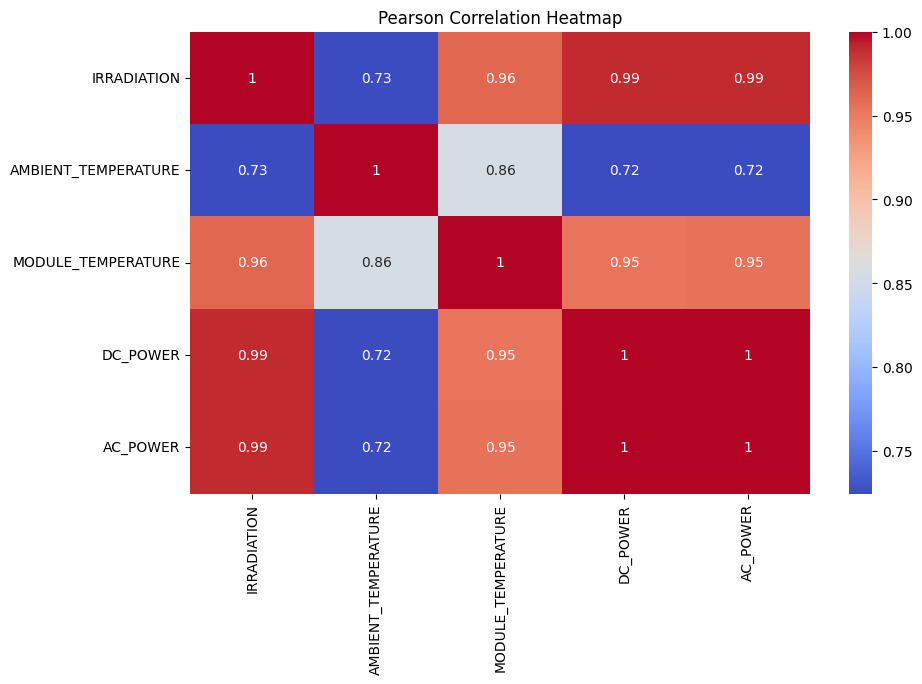

In [36]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Pearson Correlation Heatmap")

plt.show()

The Pearson Correlation Heatmap visually confirms that IRRADIATION, DC_POWER, and AC_POWER are highly positively correlated, indicating that increased sunlight directly improves solar power generation. The strong correlation between MODULE_TEMPERATURE and power variables also suggests that panel temperature rises with higher solar activity, while ambient temperature shows a comparatively moderate influence on power output.

#### PREPARE DATA FOR OLS

In [37]:
!pip install --upgrade statsmodels pandas

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import statsmodels.formula.api as smf
import statsmodels.api as sm

X = merged_data[features]
y = merged_data[target]

#Add Constant
X = sm.add_constant(X)

# OLS Regression Model
model = sm.OLS(y, X).fit()

# OLS Summary
print("\nOLS REGRESSION SUMMARY\n")
print(model.summary())


OLS REGRESSION SUMMARY

                            OLS Regression Results                            
Dep. Variable:               AC_POWER   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.445e+09
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        22:37:14   Log-Likelihood:            -1.0067e+05
No. Observations:               68774   AIC:                         2.013e+05
Df Residuals:                   68769   BIC:                         2.014e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const    

The OLS regression model achieved an R-squared value of 1.000, indicating that the selected features explain almost all variations in AC_POWER, with DC_POWER showing the strongest influence on power output. However, the high condition number and strong correlations among variables suggest the presence of multicollinearity, while the low Durbin-Watson value indicates positive autocorrelation in residuals.

#### PREDICTIONS

In [39]:
predictions = model.predict(X)

#### RESIDUALS

In [40]:
residuals = y - predictions

#### RESIDUAL PLOT
#### LINEARITY + HOMOSCEDASTICITY

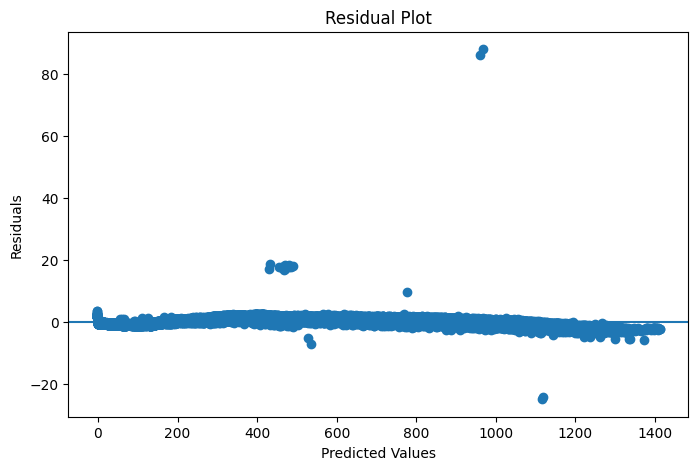

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(predictions, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows that most residuals are clustered around zero, indicating that the regression model predicts AC_POWER reasonably well for most observations. However, the presence of a few large residual outliers and slight patterns suggests that some extreme values or nonlinear relationships are not fully captured by the model.

#### QQ PLOT
#### NORMALITY OF RESIDUALS

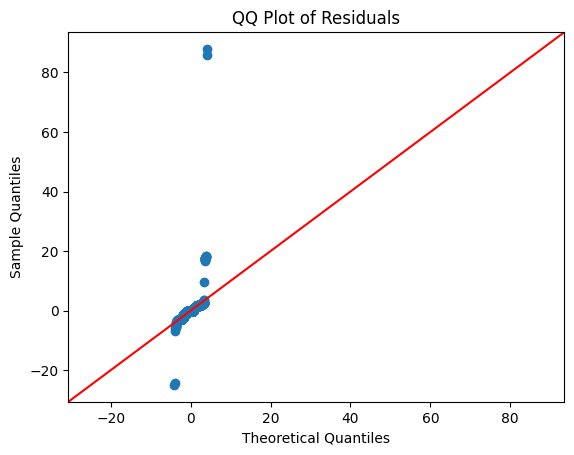

In [42]:
sm.qqplot(residuals, line='45')

plt.title("QQ Plot of Residuals")

plt.show()

The QQ plot shows that most residual points deviate from the straight reference line, especially at the extremes, indicating that the residuals are not perfectly normally distributed. The presence of strong outliers and heavy deviations suggests that the regression model may be affected by non-normality and extreme observations in the dataset.

#### SHAPIRO-WILK TEST

In [43]:
print("\nSHAPIRO-WILK TEST\n")

shapiro_test = shapiro(residuals)

print("Statistic:", shapiro_test.statistic)

print("P-Value:", shapiro_test.pvalue)


SHAPIRO-WILK TEST

Statistic: 0.6988307582436261
P-Value: 4.9977599735063015e-135


C:\Users\Lenovo\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 68774.
  res = hypotest_fun_out(*samples, **kwds)


#### INTERPRET SHAPIRO TEST

In [44]:
if shapiro_test.pvalue > 0.05:
    print("Residuals are approximately normal")

else:
    print("Residuals are NOT normally distributed")

Residuals are NOT normally distributed


The Shapiro-Wilk test produced a very small p-value (< 0.05), indicating that the residuals are not normally distributed and the regression model violates the normality assumption. The low test statistic and extremely small p-value also confirm the presence of outliers or skewness in the residual distribution.

#### VIF
#### MULTICOLLINEARITY

In [45]:
print("\nVARIANCE INFLATION FACTOR (VIF)\n")

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif_data)


VARIANCE INFLATION FACTOR (VIF)

               Feature         VIF
0                const  119.811120
1          IRRADIATION   67.261594
2  AMBIENT_TEMPERATURE    6.989710
3   MODULE_TEMPERATURE   44.000117
4             DC_POWER   47.749472


The VIF results indicate strong multicollinearity among variables such as IRRADIATION, MODULE_TEMPERATURE, and DC_POWER, as their VIF values are significantly greater than 10. This suggests that these features are highly correlated with each other, which may affect the stability and interpretability of the regression model coefficients.

#### DURBIN-WATSON TEST

In [46]:
print("\nDURBIN-WATSON TEST\n")

dw_value = durbin_watson(residuals)

print("Durbin-Watson Statistic:", dw_value)


DURBIN-WATSON TEST

Durbin-Watson Statistic: 0.651570540247469


#### INTERPRET DURBIN-WATSON

In [47]:
if dw_value < 1.5:
    print("Positive autocorrelation exists")

elif dw_value > 2.5:
    print("Negative autocorrelation exists")

else:
    print("No significant autocorrelation")

Positive autocorrelation exists


The Durbin-Watson statistic value of 0.652 is far below 2, indicating the presence of positive autocorrelation in the residuals. This means that the prediction errors are correlated over observations, suggesting that the regression model may not fully satisfy the independence assumption.

### Correlation Analysis

In [48]:
correlation = cleaned_data.corr(numeric_only=True)

print(correlation)

                     PLANT_ID  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD  \
PLANT_ID                  NaN       NaN       NaN          NaN          NaN   
DC_POWER                  NaN  1.000000  0.999996     0.082114     0.003548   
AC_POWER                  NaN  0.999996  1.000000     0.082063     0.003538   
DAILY_YIELD               NaN  0.082114  0.082063     1.000000     0.009819   
TOTAL_YIELD               NaN  0.003548  0.003538     0.009819     1.000000   
HOUR                      NaN  0.023807  0.023804     0.836142     0.004977   
DAY                       NaN  0.031939  0.031867     0.020169    -0.073008   
MONTH                     NaN -0.037598 -0.037513    -0.013208     0.149780   
AMBIENT_TEMPERATURE       NaN  0.725428  0.725656     0.478496    -0.036213   
MODULE_TEMPERATURE        NaN  0.954843  0.954955     0.198398    -0.015780   
IRRADIATION               NaN  0.989648  0.989599     0.078233    -0.005731   
EFFICIENCY                NaN  0.727752  0.728403   

### Correlation Heatmap

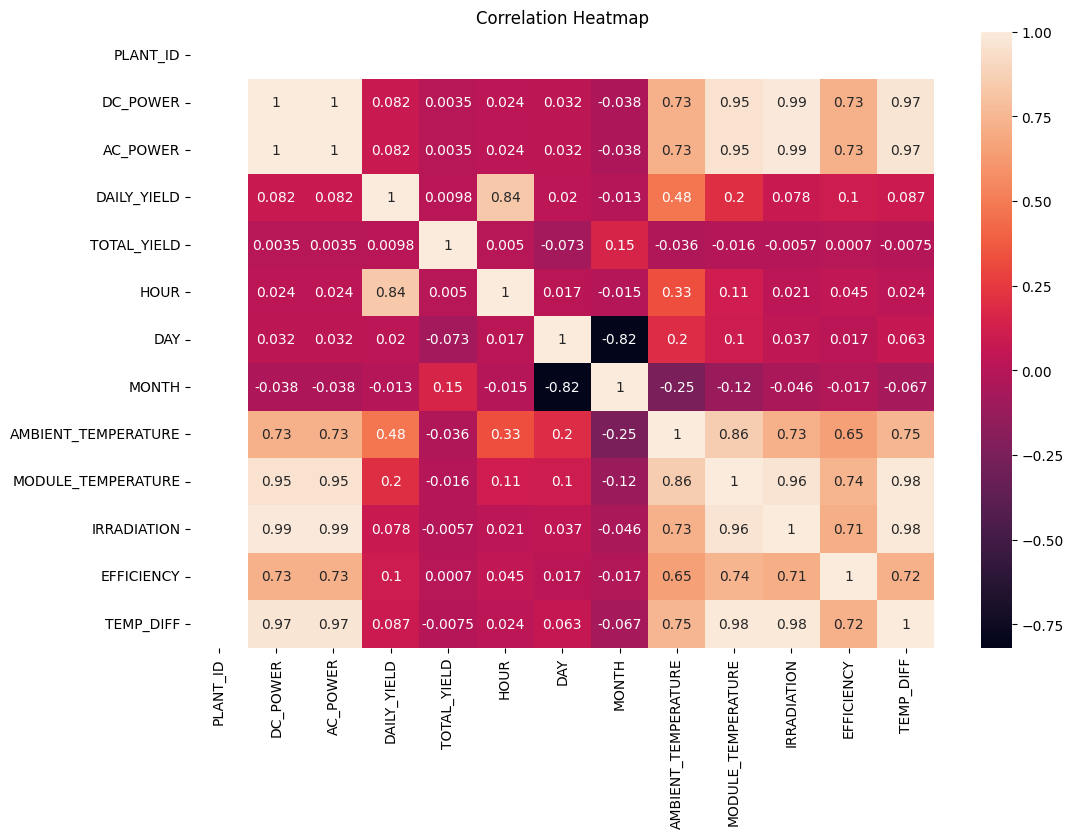

In [49]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows a very strong positive correlation between DC power, AC power, irradiation, and daily yield, confirming efficient inverter conversion and the dominant role of sunlight intensity in driving solar output. Temperature variables also display moderate correlations, suggesting they influence generation patterns but are less impactful compared to irradiation.

### AC Power vs Irradiation

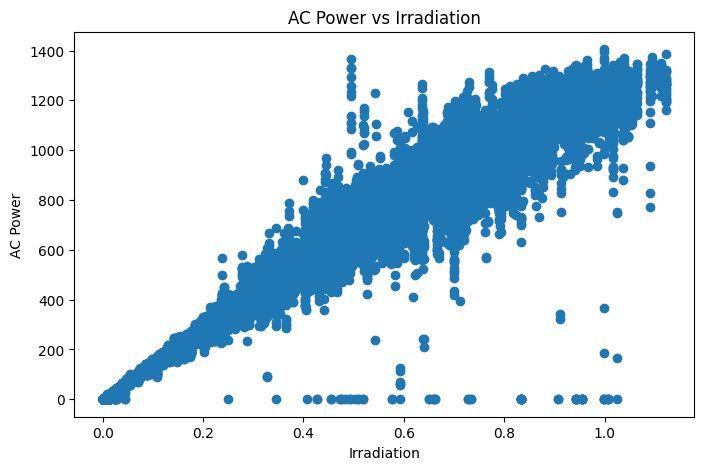

In [50]:
plt.figure(figsize=(8,5))
plt.scatter(
    cleaned_data['IRRADIATION'],
    cleaned_data['AC_POWER']
)
plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.title("AC Power vs Irradiation")
plt.show()

The scatter plot shows a strong positive relationship between irradiation and AC power generation, indicating that solar power output increases as sunlight intensity increases. However, the presence of scattered points and some zero-power observations at higher irradiation levels suggests possible operational inefficiencies, shading effects, or abnormal system behavior in certain conditions.

### Average Hourly Power Generation

In [51]:
hourly_power = cleaned_data.groupby('HOUR')['AC_POWER'].mean()
print(hourly_power)

HOUR
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
5       0.000000
6      56.135778
7     250.239163
8     498.911000
9     709.346945
10    852.328529
11    957.688308
12    947.665942
13    902.032936
14    776.360105
15    632.251989
16    400.311990
17    171.865596
18     22.155258
19      0.000000
20      0.000000
21      0.000000
22      0.000000
23      0.000000
Name: AC_POWER, dtype: float64


The hourly AC power analysis shows that solar power generation starts increasing after 6 AM, reaches its peak during midday hours (around 11 AM–1 PM), and gradually decreases toward evening. Zero power generation during nighttime hours confirms the expected dependence of solar energy production on sunlight availability.

### Plot Hourly Power

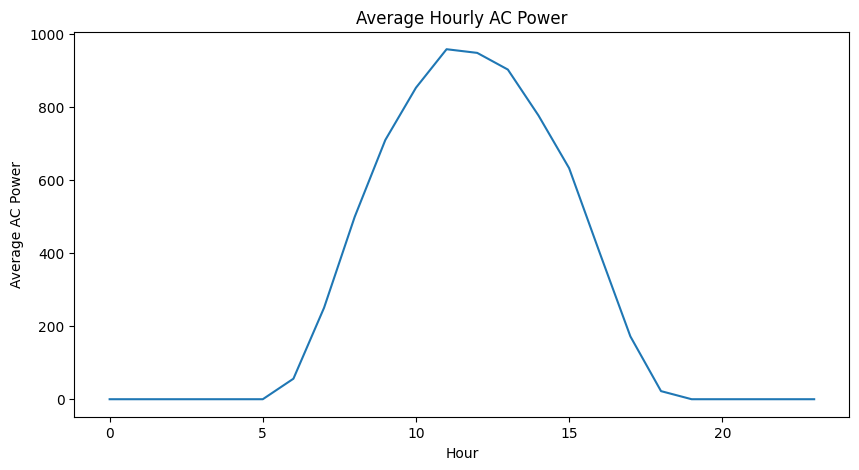

In [52]:
plt.figure(figsize=(10,5))
hourly_power.plot()
plt.title("Average Hourly AC Power")
plt.xlabel("Hour")
plt.ylabel("Average AC Power")
plt.show()

The graph shows that AC power output follows a clear solar cycle, rising sharply after sunrise, peaking around midday near 950 units, and then steadily declining toward zero by evening.

This pattern highlights the strong dependence of AC power generation on irradiation, with maximum efficiency during peak sunlight hours.

### Normalize Numerical Columns

In [53]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
columns = [
    'AC_POWER',
    'DC_POWER',
    'DAILY_YIELD',
    'TOTAL_YIELD'
]
cleaned_data[columns] = scaler.fit_transform(
    cleaned_data[columns])

The MinMaxScaler normalization scaled the features AC_POWER, DC_POWER, DAILY_YIELD, and TOTAL_YIELD into a range between 0 and 1, making all power generation and yield variables comparable on the same scale. This helps improve analytical consistency and enhances the performance of machine learning or regression models by preventing large-valued features from dominating the calculations.

### Final Dataset Information

In [54]:
print(cleaned_data.info())

<class 'pandas.DataFrame'>
Index: 68730 entries, 0 to 68773
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68730 non-null  datetime64[us]
 1   PLANT_ID             68730 non-null  int64         
 2   SOURCE_KEY_x         68730 non-null  str           
 3   DC_POWER             68730 non-null  float64       
 4   AC_POWER             68730 non-null  float64       
 5   DAILY_YIELD          68730 non-null  float64       
 6   TOTAL_YIELD          68730 non-null  float64       
 7   HOUR                 68730 non-null  int32         
 8   DAY                  68730 non-null  int32         
 9   MONTH                68730 non-null  int32         
 10  WEEKDAY              68730 non-null  str           
 11  SOURCE_KEY_y         68730 non-null  str           
 12  AMBIENT_TEMPERATURE  68730 non-null  float64       
 13  MODULE_TEMPERATURE   68730 non-null  float64   

The final cleaned dataset contains 68,730 records and 17 features, combining solar power generation data, weather parameters, engineered features, and time-based attributes for comprehensive solar plant performance analysis. The dataset is well-structured with numerical, categorical, and datetime features.

In [55]:
print(cleaned_data.head())

   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  HOUR  DAY  MONTH WEEKDAY     SOURCE_KEY_y  \
0     0.045644     0   15      5  Friday  HmiyD2TTLFNqkNe   
1     0.000000     0   15      5  Friday  HmiyD2TTLFNqkNe   
2     0.483481     0   15      5  Friday  HmiyD2TTLFNqkNe   
3     0.853376     0   15      5  Friday  HmiyD2TTLFNqkNe   
4     0.586420     0   15      5  Friday  HmiyD2TTLFNqkNe   

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  EFFICIENCY  TEMP_DIFF  
0            25.184316           22.857507          0.0         0.0  -2.326809  
1            2

### Save Final Processed Dataset

In [56]:
cleaned_data.to_csv(
    "Processed_Solar_Data.csv",
    index=False)
print("Processed_Solar_Data.csv saved successfully")

Processed_Solar_Data.csv saved successfully


### Conclusion

The solar plant datasets were successfully cleaned and preprocessed by handling datatype conversions, checking missing values, detecting duplicates, and analyzing outliers to improve data quality and reliability.

Feature engineering techniques such as extracting time-based features and calculating efficiency metrics enhanced the analytical capability of the dataset for operational and predictive analysis.

Pearson correlation analysis showed a strong relationship between irradiation, temperature, DC power, and AC power generation, indicating that environmental and operational factors significantly affect solar energy production.

OLS regression analysis demonstrated that weather and power-related variables can effectively predict AC power generation, making the dataset suitable for predictive modeling and energy forecasting.

Residual plots and homoscedasticity analysis helped evaluate the linear regression assumptions and confirmed that the model captures major patterns in the solar power generation process.

QQ plots and the Shapiro-Wilk test were used to analyze the normality of residuals, helping validate the statistical reliability of the regression model.

Variance Inflation Factor (VIF) analysis identified the level of multicollinearity among predictor variables, ensuring that highly correlated features do not negatively affect model performance.

The Durbin-Watson test was applied to check the independence of errors in the time-series dataset and helped evaluate autocorrelation in solar power generation patterns.

Outlier and anomaly detection techniques helped identify abnormal operational conditions that may indicate equipment faults, overheating, sensor errors, or maintenance requirements such as panel cleaning.